# GRU

인공지능 차세대 톱스타, 한국인 조경현 교수


<img src="https://d.pr/i/5xtgUb+" width="500"/>


**GRU(Gated Recurrent Unit)**는 RNN의 변형 구조 중 하나로, **LSTM(Long Short-Term Memory)**와 유사하지만 구조가 더 간단하다. GRU는 **게이트 구조**를 사용해 RNN의 **기울기 소멸 문제**를 해결하면서도, 연산량을 줄이고 효율적으로 학습할 수 있도록 설계되었다.(문제에 따라 LSTM보다 더 나은 경우도 있다.)


1. **단순화된 구조**
   - GRU는 LSTM에서 사용되는 **셀 상태(Cell State)**와 **은닉 상태(Hidden State)**를 하나로 통합하여 **은닉 상태(h)**만 유지한다.
   - LSTM의 3가지 게이트(망각, 입력, 출력 게이트) 대신, GRU는 **업데이트 게이트(Update Gate)**와 **리셋 게이트(Reset Gate)**의 2가지 게이트만 사용한다.

2. **장단기 의존성 처리**
   - GRU는 중요한 정보는 기억하고, 불필요한 정보는 잊는 과정을 통해 장기 의존성과 단기 의존성을 모두 처리할 수 있다.

3. **연산 효율성**
   - 구조가 단순하기 때문에 LSTM보다 계산량이 적고, 학습 속도가 더 빠르다.

**GRU의 게이트 구조**

1. **리셋 게이트 (Reset Gate)**  
   - 과거 정보를 **얼마나 잊을지** 결정한다.
   - 이전 은닉 상태가 현재 입력에 얼마나 반영될지를 제어한다.  
   - 수식:  
$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

2. **은닉 상태 업데이트**  
   - 새로운 은닉 상태는 리셋 게이트를 적용한 이전 은닉 상태와 현재 입력 정보를 결합하여 생성된다.  
   - 수식:  
$$
\tilde{h}_t = \tanh(W_h \cdot [r_t \cdot h_{t-1}, x_t] + b_h)
$$

3. **업데이트 게이트 (Update Gate)**  
   - 정보의 **기억 여부**를 결정한다.
   - 이전 시점의 정보와 현재 입력 정보를 결합하여 다음 은닉 상태에 어떤 정보를 전달할지 제어한다.  
   - 수식:  
$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$



4. **최종 은닉 상태**  
   - 업데이트 게이트를 사용해 이전 은닉 상태와 새로운 은닉 상태를 조합하여 최종 은닉 상태를 계산한다.  
   - 수식:  
$$
h_t = (1 - z_t) \cdot h_{t-1} + z_t \cdot \tilde{h}_t
$$

**GRU와 LSTM의 차이점**

| **특징**            | **LSTM**                                          | **GRU**                                  |
|----------------------|--------------------------------------------------|------------------------------------------|
| **게이트 수**        | 3개 (입력, 망각, 출력 게이트)                    | 2개 (업데이트 게이트, 리셋 게이트)              |
| **상태**            | 셀 상태(Cell State), 은닉 상태(Hidden State)      | 은닉 상태(Hidden State)만 사용           |
| **구조의 복잡성**   | 복잡함                                           | 단순함                                   |
| **계산량**          | 상대적으로 많음                                  | 상대적으로 적음                          |
| **성능 차이**        | 복잡한 시퀀스 데이터에 강점                      | 빠르고 간단한 시퀀스 데이터에 적합        |

In [26]:
import torch
import torch.nn as nn

batch_size = 2  # B (배치) : 한 번에 처리할 샘플수
seq_len = 3     # T (타임스텝) : 시퀀스 길이
input_size = 4  # F (입력 차원) : vocab_size 또는 임베딩 차원
hidden_size = 5 # H : GRU 은닉 상태 차

x = torch.randn(batch_size,seq_len,input_size)  # 입력 시퀀스 (B, T, F)
print(x.shape)
print()

# GRU 생성 (B, T, F 형태 입력)
gru = nn.GRU(input_size , hidden_size, batch_first= True)
output , hidden = gru(x)    # 순전파 후 (출력, 마지막 은닉) 

print(output.shape) # (B, T, H) : 모든 시점의 은닉 출력들이 쌓인 결과
print()
print(hidden.shape) # (num_layers, B, H)  : 마지막 시점 은닉 상태(레이어별)

torch.Size([2, 3, 4])

torch.Size([2, 3, 5])

torch.Size([1, 2, 5])


In [27]:
from tensorflow.keras.datasets import imdb

vocab_size =300

(X_train, y_train), (X_test,y_test) = imdb.load_data(num_words = vocab_size)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(25000,) (25000,)
(25000,) (25000,)


In [28]:
# 단어 사전 확인
word_index = imdb.get_word_index()

# index_word 생성 (정수 시퀀스를 사람이 읽을 수 있는 형태의 시퀀스로 복원시 사용)
index_from = 3
# ID -> 단어 역매핑 사전(상위 300개 단어만)
index_word = {index+index_from : word for word, index in word_index.items() if index <= vocab_size}

index_word[0]= '[PAD]'      # 패딩토큰
index_word[1]= '[START]'    # 문장 시작 토큰
index_word[2]= '[UNK]'      # OOV 토큰
index_word = dict(sorted(index_word.items(),key=lambda x:x[0])) # 인덱스 기준 오름차순 정렬
index_word

{0: '[PAD]',
 1: '[START]',
 2: '[UNK]',
 4: 'the',
 5: 'and',
 6: 'a',
 7: 'of',
 8: 'to',
 9: 'is',
 10: 'br',
 11: 'in',
 12: 'it',
 13: 'i',
 14: 'this',
 15: 'that',
 16: 'was',
 17: 'as',
 18: 'for',
 19: 'with',
 20: 'movie',
 21: 'but',
 22: 'film',
 23: 'on',
 24: 'not',
 25: 'you',
 26: 'are',
 27: 'his',
 28: 'have',
 29: 'he',
 30: 'be',
 31: 'one',
 32: 'all',
 33: 'at',
 34: 'by',
 35: 'an',
 36: 'they',
 37: 'who',
 38: 'so',
 39: 'from',
 40: 'like',
 41: 'her',
 42: 'or',
 43: 'just',
 44: 'about',
 45: "it's",
 46: 'out',
 47: 'has',
 48: 'if',
 49: 'some',
 50: 'there',
 51: 'what',
 52: 'good',
 53: 'more',
 54: 'when',
 55: 'very',
 56: 'up',
 57: 'no',
 58: 'time',
 59: 'she',
 60: 'even',
 61: 'my',
 62: 'would',
 63: 'which',
 64: 'only',
 65: 'story',
 66: 'really',
 67: 'see',
 68: 'their',
 69: 'had',
 70: 'can',
 71: 'were',
 72: 'me',
 73: 'well',
 74: 'than',
 75: 'we',
 76: 'much',
 77: 'been',
 78: 'bad',
 79: 'get',
 80: 'will',
 81: 'do',
 82: 'also',


In [29]:
print(X_train[0])
decoded = ''.join([index_word.get(seq,'?')for seq in X_train[0]])
decoded

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 284, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


"[START]thisfilmwasjust[UNK][UNK][UNK][UNK]story[UNK][UNK]really[UNK]theparttheyplayedandyoucouldjust[UNK]beingthere[UNK][UNK]isan[UNK]actorandnowthesamebeingdirector[UNK][UNK][UNK]fromthesame[UNK][UNK]as[UNK]soi[UNK]thefacttherewasareal[UNK]withthisfilmthe[UNK][UNK][UNK]thefilmweregreatitwasjust[UNK]somuchthati[UNK]thefilmas[UNK]asitwas[UNK]for[UNK]andwould[UNK]itto[UNK]towatchandthe[UNK][UNK]was[UNK]really[UNK]attheenditwasso[UNK]andyouknowwhattheysayifyou[UNK]atafilmitmusthavebeengoodandthis[UNK]wasalso[UNK]tothetwolittle[UNK]thatplayedthe[UNK]of[UNK]and[UNK]theywerejust[UNK][UNK]are[UNK][UNK]outofthe[UNK][UNK]ithinkbecausethe[UNK]thatplaythemall[UNK]uparesuchabig[UNK]forthewholefilmbutthese[UNK]are[UNK]andshouldbe[UNK]forwhattheyhavedonedon'tyouthinkthewholestorywasso[UNK]becauseitwastrueandwas[UNK]lifeafterallthatwas[UNK]withusall"

In [30]:
# 학습 및 테스트 데이터셋 샘플수 조절
train_size = 15000
test_size = 10000

X_train = X_train[:train_size]
y_train = y_train[:train_size]

X_test = X_test[:test_size]
y_test = y_test[:test_size]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(15000,) (15000,)
(10000,) (10000,)


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

# Pytorch Tensor 형태로 뱐환 (X데이터는 LongTensor, y데이터는 FloatTensor)
X_train = [torch.tensor(seq, dtype=torch.long) for seq in X_train]
X_test = [torch.tensor(seq, dtype=torch.long) for seq in X_test]


# 라벨데이터는 2차원 형태 (N,) -> (N,1)
y_train = torch.tensor(y_train, dtype=torch.float).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float).unsqueeze(1)


In [32]:
# 패딩 처리
import torch.nn.functional as F

seq_len = 100

# 시퀀스들을 maxlen  길이로 패딩(0) 또는 트런케이팅 하여 텐서로 변환
def pad_sequences(sequences, maxlen):
    padded_sequences = []   # 패딩 완료된 리스트

    for seq in sequences:   # 각 샘플 순회
        if len(seq) < maxlen:   # maxlen보다 짧으면 패딩처리
            padded_seq = F.pad(seq, (0,maxlen - len(seq)),value=0)  # 오른쪽에 0으로 채워 길이 맞춤
        else:       # maxlen보다 길면
            padded_seq = seq[:maxlen]   # maxlen 길이에서 자름
        padded_sequences.append(padded_seq) # 패딩 처리된 결과 누적
    return torch.stack(padded_sequences)    # 리스트를 (N, maxlen) 텐서로 스택(쌓음)


X_train_padded = pad_sequences(X_train,seq_len)
X_test_padded = pad_sequences(X_test,seq_len)

X_train_padded.shape, X_test_padded.shape

(torch.Size([15000, 100]), torch.Size([10000, 100]))

In [33]:
# GRU 분류 모델 : 임베딩 -> GRU -> FC 로 감성(이진)분석 logit을 출력하는 모델
class GRUSentimentNet(nn.Module):
    def __init__(self, vocab_size,embedding_dim,hidden_dim):
        super().__init__()  # nn.Module 초기화
        self.embedding = nn.Embedding(  # 임베딩 (0은 학습영향 최소화)
            vocab_size, 
            embedding_dim, 
            padding_idx = 0
        )
        self.gru = nn.GRU(      # GRU 입력 : 임베딩 -> 출력 : 은닉상태
            embedding_dim,
            hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim,1)   # 마지막 은닉상태 -> 이진로짓 1개

    def forward(self,x):
        x = self.embedding(x)           # (B,T) -> (B,T,E)
        output,hidden = self.gru(x)     # output : (B,T,E), hidden : (L,B,H)
        output = self.fc(hidden[-1])    # 입력 : 마지막 레이어의 마지막 은닉상태 (B,H) ->  출력 : (B,1)
        return output   # sigmoid 적용 전 원시 logit

model = GRUSentimentNet(vocab_size, embedding_dim = 100, hidden_dim = 16)
model

GRUSentimentNet(
  (embedding): Embedding(300, 100, padding_idx=0)
  (gru): GRU(100, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [34]:
# GRU구조 확인 

for name, param in model.named_parameters():
    print(name, param.shape)    # 파라미터 이름과 텐서 shape 출력

embedding.weight torch.Size([300, 100])
gru.weight_ih_l0 torch.Size([48, 100])
gru.weight_hh_l0 torch.Size([48, 16])
gru.bias_ih_l0 torch.Size([48])
gru.bias_hh_l0 torch.Size([48])
fc.weight torch.Size([1, 16])
fc.bias torch.Size([1])


In [35]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
GRUSentimentNet                          --
├─Embedding: 1-1                         30,000
├─GRU: 1-2                               5,664
├─Linear: 1-3                            17
Total params: 35,681
Trainable params: 35,681
Non-trainable params: 0

In [36]:
# 양방향 GRU 분류 모델 : 임베딩 -> 양방향 GRU -> FC 로 감성(이진)분석 logit을 출력하는 모델
class BiGRUSentimentNet(nn.Module):
    def __init__(self, vocab_size,embedding_dim,hidden_dim):
        super().__init__()  # nn.Module 초기화
        self.embedding = nn.Embedding(  # 임베딩 (0은 학습영향 최소화)
            vocab_size, 
            embedding_dim, 
            padding_idx = 0
        )
        self.gru = nn.GRU(      # GRU 입력 : 임베딩 -> 출력 : 은닉상태/ 양방향 GRU사용
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional= True
        )
        self.fc = nn.Linear(hidden_dim*2,1)   # 정/역방향 마지막 은닉상태 결합(2H) -> 이진 로짓 1개

    # 마지막 은닉상태 (정/역)을 결합해 문장 표현을 만들고 logit 계산
    def forward(self,x):
        x = self.embedding(x)           # (B,T) -> (B,T,E)
        output,hidden = self.gru(x)     # output : (B,T,E), hidden : (L*2,B,H)

        # 양방향 은닉상태 처리
        forward_pass = hidden[-2]       # 정방향 마지막 레이어 은닉상태 (B,H)
        backward_pass = hidden[-1]      # 역방향 마지막 레이어 은닉상태 (B,H)
        hidden_merged = torch.cat((forward_pass,backward_pass), dim=1)  # (B,H) + (B,H) -> (B,2H)

        output = self.fc(hidden_merged)    # 입력 : 마지막 레이어의 마지막 은닉상태 (B,H) ->  출력 : (B,1)
        return output   # sigmoid 적용 전 원시 logit

model = BiGRUSentimentNet(vocab_size, embedding_dim = 100, hidden_dim = 16)
model

BiGRUSentimentNet(
  (embedding): Embedding(300, 100, padding_idx=0)
  (gru): GRU(100, 16, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [37]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
BiGRUSentimentNet                        --
├─Embedding: 1-1                         30,000
├─GRU: 1-2                               11,328
├─Linear: 1-3                            33
Total params: 41,361
Trainable params: 41,361
Non-trainable params: 0

In [38]:
# 학습 데이터 준비
# DataLoader 구성
from torch.utils.data import random_split, DataLoader, TensorDataset

batch_size = 64
train_size = int(len(X_train_padded) * 0.8)  # 80% 학습데이터
val_size = len(X_train_padded) - train_size  # 나머지 20% 검증데이터

# 학습 / 검증 데이터셋 분리 (X, y 데이터 묶은 후에 랜덤 분리) / 테스트 데이터셋 생성
train_dataset, val_dataset = random_split(
    TensorDataset(X_train_padded, y_train), [train_size, val_size]
)
test_dataset = TensorDataset(X_test_padded,y_test)

# 학습용 : 섞어서 배치 생성 / 검증용 : 순서 유지 / 테스트용 : 순서 유지
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [39]:
# 학습 준비
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # GPU 가용시 GPU 사용
print(f'device : {device}')

torch.cuda.empty_cache()  # GPU 미사용 캐시 메모리 정리 (OOM 대비)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()  # 이진분류 손실함수 (내부 sigmoid 포함)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# 검증 손실 개선 정체시 학습률 점차적으로 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,          # 정용할 옵티마이저
    mode = 'min',       # val_loss가 최소화되는 방향 
    factor= 0.5,        # 학습률 감소 비율
    patience= 3         # 개선이 없을 경우 기다릴 에폭
)

epochs = 100

# 시각화용 지표
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# 조기종료 관련
early_stopping_patience = 5
best_val_loss = float('inf')
early_stopping_counter = 0

device : cpu


In [40]:
from tqdm.auto import tqdm

# 학습
for epoch in tqdm(range(epochs)):
    total_loss, correct, total = 0, 0, 0

    # 학습
    model.train()
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()           # 이전 기울기 초기화
        output = model(inputs)          # 순전파 
        loss = criterion(output, labels)    # 손실 계산
        loss.backward()     # 역전파 : 기울기 계산
        optimizer.step()    # 파라미터 업데이트

        total_loss += loss.detach().cpu().item()   # 손실 누적(그래프 분리하고 숫자만 누적)
        p = torch.sigmoid(output)
        pred = (p >= 0.5).float()   # 임계값 기반 예측 (1.0 / 0.0)
        correct += (pred == labels).sum().float().detach().cpu().item() # 정답 누적 (그래프 분리하고 숫자만)
        total += len(labels)
    
    train_loss = total_loss / len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct / total
    train_accs.append(train_acc)

    # 검증
    model.eval()    # 퍙가 모드
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():   # 검증시에는 기울기 계산 비활성화
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            output = model(val_inputs)
            loss = criterion(output, val_labels)

            val_loss += loss.detach().cpu().item() 
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            val_correct += (pred == val_labels).sum().float().detach().cpu().item()
            val_total += len(val_labels)

    val_loss = val_loss / len(val_dataloader)
    val_losses.append(val_loss)
    val_acc = val_correct / val_total
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    lr = scheduler.get_last_lr()[0]


    print(f"Epoch {epoch+1}/{epochs}: Train Loss : {train_loss:.4f}, Train Acc : {train_acc:.4f}, \
    Val Loss : {val_loss:.4f}, Val Acc : {val_acc:.4f}, lr : {lr}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f"{epoch + 1}에서 조기종료!")
            break

  1%|          | 1/100 [00:06<10:18,  6.25s/it]

Epoch 1/100: Train Loss : 0.6962, Train Acc : 0.5129,     Val Loss : 0.6979, Val Acc : 0.5050, lr : 0.0001


  2%|▏         | 2/100 [00:12<10:34,  6.47s/it]

Epoch 2/100: Train Loss : 0.6925, Train Acc : 0.5277,     Val Loss : 0.6966, Val Acc : 0.5073, lr : 0.0001


  3%|▎         | 3/100 [00:19<10:40,  6.60s/it]

...

Epoch 47/100: Train Loss : 0.4772, Train Acc : 0.7749,     Val Loss : 0.6083, Val Acc : 0.6940, lr : 0.0001


 48%|████▊     | 48/100 [06:09<06:08,  7.09s/it]

Epoch 48/100: Train Loss : 0.4747, Train Acc : 0.7735,     Val Loss : 0.6091, Val Acc : 0.6917, lr : 5e-05


 48%|████▊     | 48/100 [06:15<06:47,  7.83s/it]

Epoch 49/100: Train Loss : 0.4708, Train Acc : 0.7768,     Val Loss : 0.6088, Val Acc : 0.6937, lr : 5e-05
49에서 조기종료!


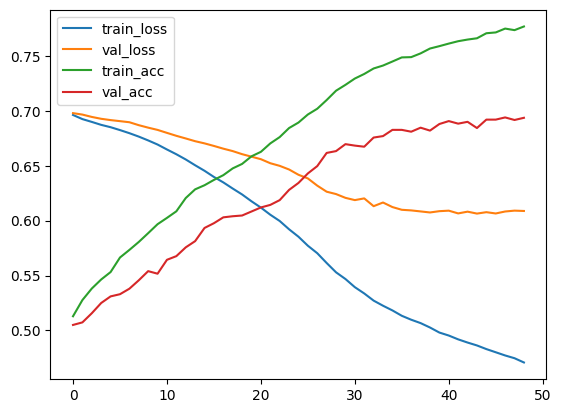

In [41]:
# 시각화

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss' : train_losses,
    'val_loss' : val_losses,
    'train_acc' : train_accs,
    'val_acc' : val_accs
})

df.plot()       # 데이터프레임을  라인 플롯으로 그림
plt.show()

In [42]:
# 테스트 데이터로 검증
def evaluate_model(model, test_dataloader,criterion, device):    
    model.to(device).eval()
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for test_inputs, test_labels in test_dataloader:
            test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

            output = model(test_inputs)
            loss = criterion(output, test_labels)

            test_loss += loss.item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            test_correct += (pred == test_labels).sum().float().detach().cpu().item()
            test_total += len(test_labels)
        test_loss = test_loss / len(test_dataloader)
        test_acc = test_correct / test_total


        return test_loss, test_acc

test_loss, test_acc = evaluate_model(model, test_dataloader,criterion, device)

print(f"Test Loss : {test_loss:.4f} , Test Acc : {test_acc:.4f}")

Test Loss : 0.5862 , Test Acc : 0.6954


In [43]:
# def movie_review_sentimental_analysis(sentences):

#     tokens = [preprocessing(sent)for sent in sentences]
#     encoded_sequences = tokenizer.texts_to_sequenmces(tokens)
#     padded_sequences = pad_sequences(encoded_sequences,maxlen=seq_len)

#     X = torch.tensor(padded_sequences,dtype=torch.long).to(device)

#     model.eval()
#     with torch.no_grad():
#         output = model(X)
#         p = torch.sigmoid(output)
#         pred = (p>= 0.5).float()

#         return ['긍정' if pr ==1 else '부정' for pr in pred]

# samples = [
#     '이 영화는 못봐주겠네',
#     '오랜만에 감동을 느꼇다~',
#     '감독이 생각이 있나?',
#     '내가 만들어도 이거보다 나을거같은데?',
#     '하츄핑보다 재미없는데?'
# ]